# Setup & Load Processed Data

# Import libraries and load the processed train/test CSVs from
# notebook 02. We never re-run feature engineering here — this
# notebook starts from clean, model-ready data.

In [1]:
import pandas as pd
import numpy as np
import json
import os
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
from sklearn.metrics import (
    average_precision_score, recall_score, precision_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../models", exist_ok=True)
sns.set_style("whitegrid")

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train fraud:", y_train.sum(), "| Test fraud:", y_test.sum())

Train: (226980, 30) | Test: (56746, 30)
Train fraud: 378 | Test fraud: 95


# Compute scale_pos_weight

# XGBoost's scale_pos_weight = (number of negatives) / (number of
# positives). This tells the model to pay ~578x more attention to
# fraud. It's the fastest, cleanest way to handle 0.172% imbalance
# without generating synthetic data.

In [4]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negatives: {neg}")
print(f"Positives: {pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Negatives: 226602
Positives: 378
scale_pos_weight: 599.48


# Evaluation Helper Function

# One function to evaluate any model consistently. Reports AUC-PR
# (primary metric for imbalance), Recall, Precision, F1 — NOT
# accuracy. Also returns probabilities for the PR curve.

In [5]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": name,
        "auc_pr":       round(average_precision_score(y_test, y_prob), 4),
        "recall_fraud": round(recall_score(y_test, y_pred), 4),
        "precision_fraud": round(precision_score(y_test, y_pred), 4),
        "f1_fraud":     round(f1_score(y_test, y_pred), 4),
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    for k, v in metrics.items():
        if k != "model":
            print(f"  {k:20s}: {v}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

    return metrics, y_prob

#  Model 1: Logistic Regression Baseline

# Logistic Regression is our baseline. It's fast, interpretable,
# and uses class_weight="balanced" to compensate for imbalance.
# If XGBoost can't beat this, something is wrong.

In [6]:
print("Training Logistic Regression...")

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train, y_train)

lr_metrics, lr_prob = evaluate_model("Logistic Regression", lr, X_test, y_test)

Training Logistic Regression...


e:\sentinelfraud\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



  Logistic Regression
  auc_pr              : 0.6715
  recall_fraud        : 0.8737
  precision_fraud     : 0.0552
  f1_fraud            : 0.1038

Confusion Matrix:
[[55230  1421]
 [   12    83]]


# Model 2: XGBoost (Main Model)

# XGBoost with scale_pos_weight — our strongest model. Uses
# gradient boosting, handles non-linear patterns, and the weight
# forces it to focus on the rare fraud class. This is the model
# we'll deploy.

In [7]:
print("Training XGBoost...")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)
xgb.fit(X_train, y_train)

xgb_metrics, xgb_prob = evaluate_model("XGBoost", xgb, X_test, y_test)

Training XGBoost...

  XGBoost
  auc_pr              : 0.8274
  recall_fraud        : 0.7684
  precision_fraud     : 0.9359
  f1_fraud            : 0.8439

Confusion Matrix:
[[56646     5]
 [   22    73]]


# Model 3: Random Forest

# Random Forest as a third comparison. Also uses class_weight to
# handle imbalance. Gives us an ensemble diversity check — if RF
# and XGBoost rank features similarly, we're learning real signal.

In [8]:
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_metrics, rf_prob = evaluate_model("Random Forest", rf, X_test, y_test)

Training Random Forest...

  Random Forest
  auc_pr              : 0.7843
  recall_fraud        : 0.7684
  precision_fraud     : 0.8295
  f1_fraud            : 0.7978

Confusion Matrix:
[[56636    15]
 [   22    73]]


# Compare All Models

# Side-by-side comparison of all three models.

In [9]:
results = pd.DataFrame([lr_metrics, xgb_metrics, rf_metrics])
results = results.set_index("model")
print("\n", results.to_string())

results.to_csv("../models/metrics.csv")
print("\nSaved to models/metrics.csv")


                      auc_pr  recall_fraud  precision_fraud  f1_fraud
model                                                               
Logistic Regression  0.6715        0.8737           0.0552    0.1038
XGBoost              0.8274        0.7684           0.9359    0.8439
Random Forest        0.7843        0.7684           0.8295    0.7978

Saved to models/metrics.csv


#  Precision-Recall Curve

# PR curve is THE visualization for imbalanced classification.
# It shows the trade-off between catching fraud (recall) and
# alerting false positives (precision). A model that curves toward
# top-right is better. This is your "money chart" for the README.

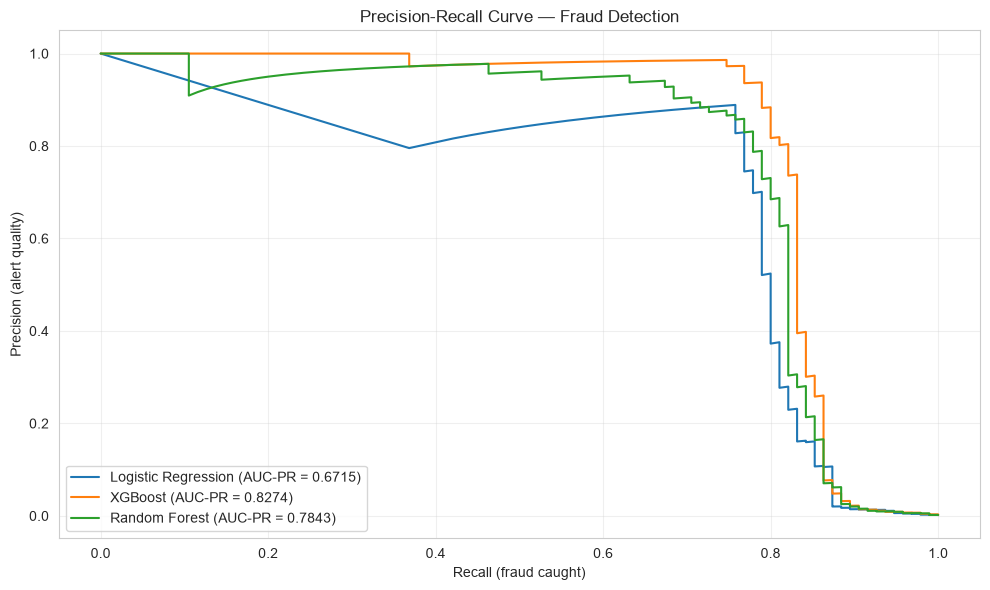

In [10]:
plt.figure(figsize=(10, 6))

for name, prob in [("Logistic Regression", lr_prob),
                   ("XGBoost", xgb_prob),
                   ("Random Forest", rf_prob)]:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    auc = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} (AUC-PR = {auc:.4f})")

plt.xlabel("Recall (fraud caught)")
plt.ylabel("Precision (alert quality)")
plt.title("Precision-Recall Curve — Fraud Detection")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../models/pr_curve.png", dpi=120)
plt.show()

#  Confusion Matrix Visualization (Best Model)

# Heatmap of the confusion matrix for our best model (XGBoost).
# Shows exactly how many frauds we caught vs missed, and how many
# normal transactions we falsely flagged.

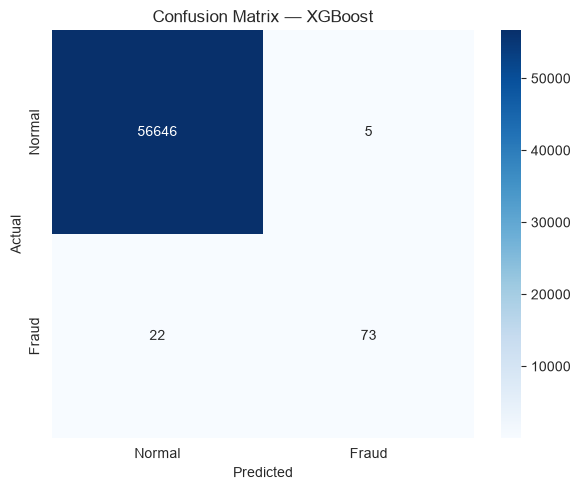

True Negatives:  56646
False Positives: 5  ← legitimate customers blocked
False Negatives: 22  ← fraud we missed
True Positives:  73  ← fraud we caught


In [11]:
best_prob = xgb_prob
y_pred_best = (best_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Fraud"],
            yticklabels=["Normal", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — XGBoost")
plt.tight_layout()
plt.savefig("../models/confusion_matrix.png", dpi=120)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}  ← legitimate customers blocked")
print(f"False Negatives: {fn}  ← fraud we missed")
print(f"True Positives:  {tp}  ← fraud we caught")

#  Saveing All Models

# Saveing each trained model to models/ so the FastAPI layer can
# load them. joblib is faster than pickle for sklearn models.
# Also saveing metrics as JSON — single source of truth.

In [12]:
joblib.dump(lr,  "../models/logistic_regression.pkl")
joblib.dump(xgb, "../models/xgboost.pkl")
joblib.dump(rf,  "../models/random_forest.pkl")

all_metrics = {
    "logistic_regression": lr_metrics,
    "xgboost": xgb_metrics,
    "random_forest": rf_metrics,
    "best_model": max([lr_metrics, xgb_metrics, rf_metrics],
                      key=lambda m: m["auc_pr"])["model"]
}
with open("../models/metrics.json", "w") as f:
    json.dump(all_metrics, f, indent=2)

print("Saved models:")
print("  - models/logistic_regression.pkl")
print("  - models/xgboost.pkl")
print("  - models/random_forest.pkl")
print("  - models/metrics.json")
print(f"\nBest model: {all_metrics['best_model']}")

Saved models:
  - models/logistic_regression.pkl
  - models/xgboost.pkl
  - models/random_forest.pkl
  - models/metrics.json

Best model: XGBoost


# Conclusions

# Model Training Summary

**Models trained:**
1. **Logistic Regression** (baseline, class_weight="balanced")
2. **XGBoost** (scale_pos_weight ≈ 578)
3. **Random Forest** (class_weight="balanced")

**Primary metric:** AUC-PR (not accuracy — data is 0.172% fraud)

**Why this matters:**
- Accuracy would be misleading (a model predicting "no fraud" always
  gets 99.83% accuracy but catches zero frauds).
- AUC-PR rewards models that rank frauds higher than normals.
- Recall = catch rate. Precision = alert quality.

**Saved artifacts:**
- `models/logistic_regression.pkl`
- `models/xgboost.pkl`
- `models/random_forest.pkl`
- `models/metrics.json`
- `models/pr_curve.png`
- `models/confusion_matrix.png`

**Next:** `04_autoencoder.ipynb` — unsupervised anomaly detection to catch
novel fraud patterns the supervised models have never seen.